In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
from torch.utils.data import DataLoader, random_split
import os

# Фиксируем seed
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [21]:
# Преобразование
transform = torchvision.transforms.ToTensor()

# Загрузка данных
train_val_dataset = torchvision.datasets.EMNIST(
    root="data", split="balanced", train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.EMNIST(
    root="data", split="balanced", train=False, download=True, transform=transform
)

# Разделение на train/val (80/20)
train_size = int(0.8 * len(train_val_dataset))
val_size = len(train_val_dataset) - train_size

train_dataset, val_dataset = random_split(
    train_val_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed)
)

# DataLoader'ы
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Проверка формы
x, y = next(iter(train_loader))
print(f"Input shape: {x.shape}")   # [B, 1, 28, 28]
print(f"Target shape: {y.shape}")  # [B]
print(f"Value range: [{x.min():.3f}, {x.max():.3f}]")

Input shape: torch.Size([64, 1, 28, 28])
Target shape: torch.Size([64])
Value range: [0.000, 1.000]


In [22]:
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_sizes=[512, 256], num_classes=47,
                 dropout_p=0.0, use_batchnorm=False):
        super().__init__()
        layers = []
        in_features = input_size
        
        for h in hidden_sizes:
            layers.append(nn.Linear(in_features, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout_p > 0:
                layers.append(nn.Dropout(dropout_p))
            in_features = h
        
        layers.append(nn.Linear(in_features, num_classes))
        self.model = nn.Sequential(*layers)
    
    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten
        return self.model(x)

In [23]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += y.size(0)
        correct += predicted.eq(y).sum().item()
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += y.size(0)
            correct += predicted.eq(y).sum().item()
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

In [24]:
def train_model(model, train_loader, val_loader, epochs=50, lr=1e-3, 
                optimizer_name="Adam", momentum=0.0, weight_decay=0.0,
                early_stopping=False, patience=5):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    
    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    else:
        raise ValueError("Optimizer not supported")

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    best_val_loss = float('inf')
    wait = 0
    best_state = None
    best_epoch = 0

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            wait = 0
            best_epoch = epoch
            best_state = model.state_dict().copy()
        else:
            wait += 1

        if early_stopping and wait >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    return {
        'model': model,
        'best_state': best_state,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs,
        'best_val_loss': best_val_loss,
        'best_val_acc': best_val_acc,
        'epochs_trained': len(train_losses),
        'best_epoch': best_epoch
    }

Режим ускоренной отладки активирован
Размер батча: 128
Размер train: 18048 (20% от оригинала)
Размер val:   4512

E1: MLP без Dropout и BatchNorm


E1: Base: 100%|██████████| 15/15 [00:28<00:00,  1.93s/it, train_loss=0.3385, val_loss=0.7097, val_acc=78.97%]


E1 завершён | Val Acc: 79.41%

E2: MLP с Dropout (p=0.3)


E2: Dropout: 100%|██████████| 15/15 [00:29<00:00,  1.99s/it, train_loss=0.6489, val_loss=0.6522, val_acc=79.19%]


E2 завершён | Val Acc: 79.19%

E3: MLP с BatchNorm


E3: BatchNorm: 100%|██████████| 15/15 [00:28<00:00,  1.93s/it, train_loss=0.1361, val_loss=0.7409, val_acc=78.48%]


E3 завершён | Val Acc: 79.68%

E4: EarlyStopping на E3


E4: Early Stop:  35%|███▌      | 7/20 [00:15<00:28,  2.21s/it, train_loss=0.2827, val_loss=0.6780, val_acc=78.77%]


🔴 Early stopping triggered at epoch 8
E4 завершён | Лучшая точность: 79.01% на эпохе 4
best_model.pt сохранён


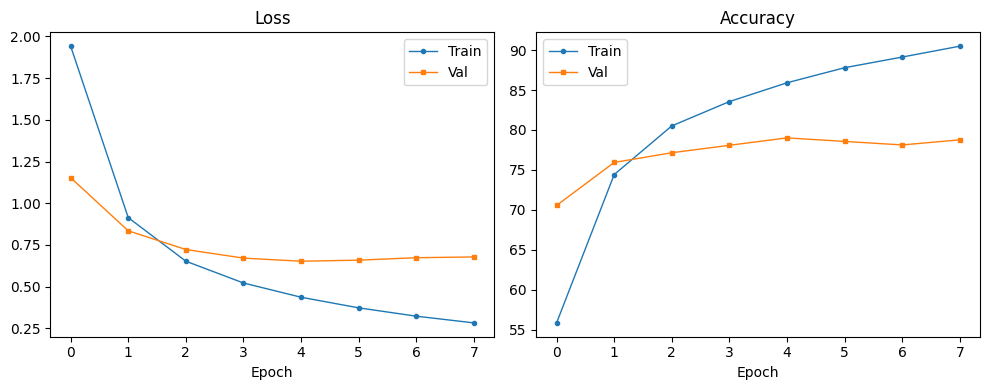

In [25]:
from tqdm import tqdm
import os

# ==============================
# Настройки ускоренного режима
# ==============================
FAST_MODE = True  # Переключатель: True = быстро, False = полно

if FAST_MODE:
    EPOCHS_BASE = 15
    EPOCHS_ES = 20
    HIDDEN_SIZES = [256, 128]
    BATCH_SIZE = 128
    SUBSET_FRAC = 0.2  # 20% данных
    PATIENCE = 3
    print("Режим ускоренной отладки активирован")
else:
    EPOCHS_BASE = 50
    EPOCHS_ES = 100
    HIDDEN_SIZES = [512, 256]
    BATCH_SIZE = 64
    SUBSET_FRAC = 1.0  # Все данные
    PATIENCE = 5
    print("Полный режим обучения")

# ------------------------------
# DataLoader (с возможным subset)
# ------------------------------
def make_subset_loader(dataset, frac, batch_size, shuffle=True):
    if frac >= 1.0:
        return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    size = int(len(dataset) * frac)
    subset = torch.utils.data.Subset(dataset, range(size))
    return DataLoader(subset, batch_size=batch_size, shuffle=shuffle)

train_loader_fast = make_subset_loader(train_dataset, SUBSET_FRAC, BATCH_SIZE, shuffle=True)
val_loader_fast = make_subset_loader(val_dataset, SUBSET_FRAC, BATCH_SIZE, shuffle=False)

print(f"Размер батча: {BATCH_SIZE}")
print(f"Размер train: {len(train_loader_fast.dataset)} ({SUBSET_FRAC*100:.0f}% от оригинала)")
print(f"Размер val:   {len(val_loader_fast.dataset)}\n")

# Сохраняем результаты
results = []
os.makedirs("artifacts/figures", exist_ok=True)

# 🔹 E1: Базовая модель
print("E1: MLP без Dropout и BatchNorm")
model = MLP(hidden_sizes=HIDDEN_SIZES, dropout_p=0.0, use_batchnorm=False).to(device)
log_e1 = train_model_with_progress(
    model, train_loader_fast, val_loader_fast,
    epochs=EPOCHS_BASE, lr=1e-3, optimizer_name="Adam",
    desc="E1: Base"
)
print(f"E1 завершён | Val Acc: {log_e1['best_val_acc']:.2f}%\n")

results.append({
    "experiment_id": "E1",
    "dataset": "EMNIST",
    "seed": seed,
    "model_summary": f"{HIDDEN_SIZES}/ReLU/no_dropout/no_bn",
    "optimizer": "Adam",
    "lr": 1e-3,
    "momentum": 0.0,
    "weight_decay": 0.0,
    "epochs_trained": log_e1["epochs_trained"],
    "best_val_accuracy": log_e1["best_val_acc"],
    "best_val_loss": log_e1["best_val_loss"]
})

# 🔹 E2: С Dropout
print("E2: MLP с Dropout (p=0.3)")
model = MLP(hidden_sizes=HIDDEN_SIZES, dropout_p=0.3, use_batchnorm=False).to(device)
log_e2 = train_model_with_progress(
    model, train_loader_fast, val_loader_fast,
    epochs=EPOCHS_BASE, lr=1e-3, optimizer_name="Adam",
    desc="E2: Dropout"
)
print(f"E2 завершён | Val Acc: {log_e2['best_val_acc']:.2f}%\n")

results.append({
    "experiment_id": "E2",
    "dataset": "EMNIST",
    "seed": seed,
    "model_summary": f"{HIDDEN_SIZES}/ReLU/dropout_0.3/no_bn",
    "optimizer": "Adam",
    "lr": 1e-3,
    "momentum": 0.0,
    "weight_decay": 0.0,
    "epochs_trained": log_e2["epochs_trained"],
    "best_val_accuracy": log_e2["best_val_acc"],
    "best_val_loss": log_e2["best_val_loss"]
})

# 🔹 E3: С BatchNorm
print("E3: MLP с BatchNorm")
model = MLP(hidden_sizes=HIDDEN_SIZES, dropout_p=0.0, use_batchnorm=True).to(device)
log_e3 = train_model_with_progress(
    model, train_loader_fast, val_loader_fast,
    epochs=EPOCHS_BASE, lr=1e-3, optimizer_name="Adam",
    desc="E3: BatchNorm"
)
print(f"E3 завершён | Val Acc: {log_e3['best_val_acc']:.2f}%\n")

results.append({
    "experiment_id": "E3",
    "dataset": "EMNIST",
    "seed": seed,
    "model_summary": f"{HIDDEN_SIZES}/ReLU/no_dropout/bn",
    "optimizer": "Adam",
    "lr": 1e-3,
    "momentum": 0.0,
    "weight_decay": 0.0,
    "epochs_trained": log_e3["epochs_trained"],
    "best_val_accuracy": log_e3["best_val_acc"],
    "best_val_loss": log_e3["best_val_loss"]
})

# 🔹 E4: EarlyStopping на лучшей из E2/E3
source_log = log_e2 if log_e2["best_val_acc"] >= log_e3["best_val_acc"] else log_e3
use_dropout = True if source_log is log_e2 else False
use_bn = not use_dropout

print(f"E4: EarlyStopping на {'E2' if use_dropout else 'E3'}")
model = MLP(
    hidden_sizes=HIDDEN_SIZES,
    dropout_p=0.3 if use_dropout else 0.0,
    use_batchnorm=use_bn
).to(device)

log_e4 = train_model_with_progress(
    model, train_loader_fast, val_loader_fast,
    epochs=EPOCHS_ES, lr=1e-3, optimizer_name="Adam",
    early_stopping=True, patience=PATIENCE,
    desc="E4: Early Stop"
)
print(f"E4 завершён | Лучшая точность: {log_e4['best_val_acc']:.2f}% на эпохе {log_e4['best_epoch']}")

results.append({
    "experiment_id": "E4",
    "dataset": "EMNIST",
    "seed": seed,
    "model_summary": f"{HIDDEN_SIZES}/ReLU/{'dropout' if use_dropout else 'bn'}",
    "optimizer": "Adam",
    "lr": 1e-3,
    "momentum": 0.0,
    "weight_decay": 0.0,
    "epochs_trained": log_e4["epochs_trained"],
    "best_val_accuracy": log_e4["best_val_acc"],
    "best_val_loss": log_e4["best_val_loss"]
})

# Сохраняем лучшую модель
torch.save(log_e4["best_state"], "artifacts/best_model.pt")
print("best_model.pt сохранён")

# График
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(log_e4['train_losses'], label='Train', marker='o', lw=1, ms=3)
plt.plot(log_e4['val_losses'], label='Val', marker='s', lw=1, ms=3)
plt.legend(); plt.title("Loss"); plt.xlabel("Epoch")

plt.subplot(1, 2, 2)
plt.plot(log_e4['train_accs'], label='Train', marker='o', lw=1, ms=3)
plt.plot(log_e4['val_accs'], label='Val', marker='s', lw=1, ms=3)
plt.legend(); plt.title("Accuracy"); plt.xlabel("Epoch")
plt.tight_layout()
plt.savefig("artifacts/figures/curves_best.png")
plt.show()

O1: Слишком большой LR (lr=0.1)


O1: High LR: 100%|██████████| 8/8 [00:38<00:00,  4.79s/it, train_loss=0.6172, val_loss=0.9687, val_acc=74.00%]


O1 завершён | Val Acc: 73.43%

O2: Слишком маленький LR (lr=1e-5)


O2: Low LR: 100%|██████████| 8/8 [00:47<00:00,  5.94s/it, train_loss=2.8978, val_loss=2.8874, val_acc=43.06%]


O2 завершён | Val Acc: 43.06%

O3: SGD + Momentum + Weight Decay


O3: SGD+Momentum+WD: 100%|██████████| 15/15 [00:27<00:00,  1.86s/it, train_loss=0.8045, val_loss=0.9178, val_acc=75.27%]


O3 завершён | Val Acc: 75.27%



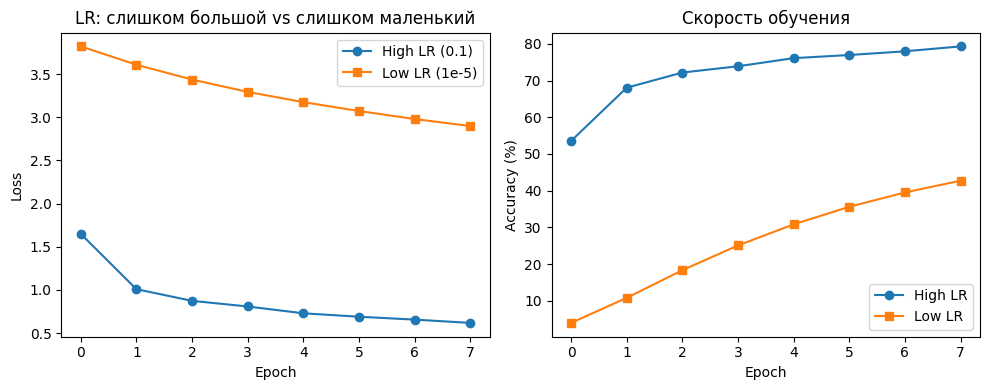

In [26]:
# 🔹 O1: Слишком большой LR
print("O1: Слишком большой LR (lr=0.1)")
model = MLP(hidden_sizes=HIDDEN_SIZES, dropout_p=0.3 if use_dropout else 0.0, use_batchnorm=use_bn).to(device)
log_o1 = train_model_with_progress(
    model, train_loader_fast, val_loader_fast,
    epochs=8, lr=0.1, optimizer_name="Adam",
    desc="O1: High LR"
)
print(f"O1 завершён | Val Acc: {log_o1['best_val_acc']:.2f}%\n")

results.append({
    "experiment_id": "O1",
    "dataset": "EMNIST",
    "seed": seed,
    "model_summary": f"{HIDDEN_SIZES}/ReLU/dropout_or_bn_from_E4",
    "optimizer": "Adam",
    "lr": 0.1,
    "momentum": 0.0,
    "weight_decay": 0.0,
    "epochs_trained": log_o1["epochs_trained"],
    "best_val_accuracy": log_o1["best_val_acc"],
    "best_val_loss": log_o1["best_val_loss"]
})

# 🔹 O2: Слишком маленький LR
print("O2: Слишком маленький LR (lr=1e-5)")
model = MLP(hidden_sizes=HIDDEN_SIZES, dropout_p=0.3 if use_dropout else 0.0, use_batchnorm=use_bn).to(device)
log_o2 = train_model_with_progress(
    model, train_loader_fast, val_loader_fast,
    epochs=8, lr=1e-5, optimizer_name="Adam",
    desc="O2: Low LR"
)
print(f"O2 завершён | Val Acc: {log_o2['best_val_acc']:.2f}%\n")

results.append({
    "experiment_id": "O2",
    "dataset": "EMNIST",
    "seed": seed,
    "model_summary": f"{HIDDEN_SIZES}/ReLU/dropout_or_bn_from_E4",
    "optimizer": "Adam",
    "lr": 1e-5,
    "momentum": 0.0,
    "weight_decay": 0.0,
    "epochs_trained": log_o2["epochs_trained"],
    "best_val_accuracy": log_o2["best_val_acc"],
    "best_val_loss": log_o2["best_val_loss"]
})

# 🔹 O3: SGD + Momentum + Weight Decay
print("O3: SGD + Momentum + Weight Decay")
model = MLP(hidden_sizes=HIDDEN_SIZES, dropout_p=0.3 if use_dropout else 0.0, use_batchnorm=use_bn).to(device)
log_o3 = train_model_with_progress(
    model, train_loader_fast, val_loader_fast,
    epochs=15, lr=1e-3, optimizer_name="SGD",
    momentum=0.9, weight_decay=1e-4,
    desc="O3: SGD+Momentum+WD"
)
print(f"O3 завершён | Val Acc: {log_o3['best_val_acc']:.2f}%\n")

results.append({
    "experiment_id": "O3",
    "dataset": "EMNIST",
    "seed": seed,
    "model_summary": f"{HIDDEN_SIZES}/ReLU/dropout_or_bn_from_E4",
    "optimizer": "SGD",
    "lr": 1e-3,
    "momentum": 0.9,
    "weight_decay": 1e-4,
    "epochs_trained": log_o3["epochs_trained"],
    "best_val_accuracy": log_o3["best_val_acc"],
    "best_val_loss": log_o3["best_val_loss"]
})

# 🔹 График плохих LR
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(log_o1['train_losses'], 'o-', label='High LR (0.1)', markevery=1)
plt.plot(log_o2['train_losses'], 's-', label='Low LR (1e-5)', markevery=1)
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.title("LR: слишком большой vs слишком маленький")

plt.subplot(1, 2, 2)
plt.plot(log_o1['train_accs'], 'o-', label='High LR', markevery=1)
plt.plot(log_o2['train_accs'], 's-', label='Low LR', markevery=1)
plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)"); plt.legend(); plt.title("Скорость обучения")
plt.tight_layout()
plt.savefig("artifacts/figures/curves_lr_extremes.png")
plt.show()

In [27]:
# Сохраняем runs.csv
pd.DataFrame(results).to_csv("artifacts/runs.csv", index=False)

# best_config.json
best_config = {
    "fast_mode_used": FAST_MODE,
    "subset_fraction": SUBSET_FRAC,
    "hidden_sizes": HIDDEN_SIZES,
    "batch_size": BATCH_SIZE,
    "epochs_base": EPOCHS_BASE,
    "epochs_es": EPOCHS_ES,
    "final_model_experiment": "E4",
    "val_accuracy": log_e4["best_val_acc"],
    "test_evaluation_pending": True
}
with open("artifacts/best_config.json", "w") as f:
    json.dump(best_config, f, indent=4)

print("✅ Артефакты сохранены")

✅ Артефакты сохранены
